# Predicting Loan Default Risk for Small Businesses

Imagine you are a loan officer working at a bank or financial institution, helping small businesses apply for loans. Every day, you review financial reports, credit histories, and other information to decide whether a business should receive a loan and what the terms should be. One of the biggest risks you face is that a business might not repay the loan, causing financial losses for the bank and potential problems for the business itself.

It can be difficult to predict which businesses might struggle to repay their loans. This is where AI can help. Imagine having an AI system that could quickly analyse all the important data-such as past loan performance, financial health, and market trends-and predict which businesses are most likely to default on their loans. This would allow you to make more informed decisions and reduce risks for both the bank and the businesses.

Your task is to design a system that can do this: an AI solution that can help predict the risk of loan default for small businesses. While you don't need to be an expert in finance, understanding the basic challenges that financial institutions face when offering loans is important.

## **Objective**

The goal of this case study is to create a plan for an AI system that uses data to predict the chances of a small business defaulting on a loan. The system should help financial institutions assess risk more accurately, so they can make better decisions when approving loan

## **Project Tasks**


- Prepare a report summarizing your findings and recommendations focusing on how the AI system can benefit your chosen application. In your report:

- Document all steps taken from data preparation to model deployment. This includes identifying data sources, data cleaning, preprocessing, and how the AI model will be integrated
    - Justify each choice made in terms of AI methodologies and tools. Explain why you selected certain models, algorithms, or techniques, and how they align with the goal of predicting loan defaults.
    - Discuss potential limitations and how they could be addressed. Consider data quality issues, potential biases, and how the model could be improved over time.
    - Focus on the rationale behind each decision and its implications. Clearly explain how your choices will affect the accuracy and effectiveness of the AI system.


### The project will involve the following tasks: 

1. Identifying Data Sources: 
o	Outline potential data sources relevant to the chosen application 
o	Discuss the criteria for selecting high-quality and relevant data 

2. ETL Processes: 
o	Explain the Extract, Transform, Load (ETL) process tailored to the application 
o	Identify tools and technologies suitable for the ETL steps 

3. Data Transformations and Manipulation: 
o	Describe necessary data cleaning, transformation, and manipulation tasks 
o	Justify the methods and techniques chosen for data preparation 

4. Data Analytics: 
o	Detail the analytical methods to explore and understand the data 
o	Include statistical analysis and preliminary findings that could influence model design 

5. Data Visualisation: 
o	Plan how to visualize data insights effectively for different stakeholders 
o	Choose appropriate visualization tools and justify their use 

6. Machine Learning Algorithms: 
o	Propose machine learning algorithms suitable for the application 
o	Justify the choice of algorithms based on the nature of the data and the expected outcomes 

7. Desired Output: 
o	Define the specific outputs expected from the AI model 
o	Discuss how these outputs will address the problem or improve the application 

8. Testing Methods: 
o	Plan the testing phases for the AI model, including both validation and verification 
o	Describe methods to measure model accuracy, precision, and other relevant metrics 

9. Ethics: 
o	Discuss ethical considerations related to data privacy, accuracy, and explainability 
o	Propose measures to address potential ethical issues in the model's application 

10. Performance Metrics: 
o	Explain how to evaluate the model using metrics like true positives, false negatives, etc. 
o	Outline plans for adjusting the model based on these metrics


Marking Rubric: Checklist for Students 

## This project will be graded as complete/not yet complete relevant to the following criteria;

### Submission Component 	Details of criteria
- Task 1	You are able to adequately identify and justify sources
- Task 2	You are able to effectively design ETL processes
- Task 3	You are able to describe and justify effective methods for data manipulation
- Task 4	You are able to detail effective techniques for data analysis 
- Task 5	You are able to plan how to visualize data insights effectively for different stakeholders, choose appropriate visualization tools and justify their use 
- Task 6	You are able to propose machine learning algorithms suitable for the application, and justify the choice of algorithms based on the nature of the data and the expected outcomes 
- Task 7	You are able to define the specific outputs expected from the AI model and discuss how these outputs will address the problem or improve the application 
- Task 8	You are able to plan the testing phases for the AI model, including both validation and verification and describe methods to measure model accuracy, precision, and other relevant metrics
- Task 9	You are able to discuss ethical considerations related to data privacy, accuracy and explainability and propose measures to address potential ethical issues in the model's application 
- Task 10	You are able to explain how to evaluate the model using metrics like true positives and false negatives, and outline plans for adjusting the model based on these metrics 


In [1]:
#!pip -q install matplotlib
#!pip -q install numpy
#!pip -q install pandas
#!pip -q install seaborn
#!pip -q install scikit-learn
#!pip install xgboost
#pip install --upgrade xgboost

In [2]:
import sys
!{sys.executable} -m pip install scikit-learn

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer

In [4]:
import warnings
warnings.filterwarnings("ignore") 

### Task 1 You are able to adequately identify and justify sources
1. Australian Prudential Regulation Authority (APRA)
APRA Statistics - 
Provides aggregate data on business lending by banks, including breakdowns by business size, industry, and state. It’s authoritative for trends and benchmarking and  useful for adding macroeconomic context. 

2. Australian Bureau of Statistics (ABS)
ABS Business Characteristics Survey - https://www.abs.gov.au/
Microdata and summary statistics on business finance, access to credit, business performance, and demographics. Useful for feature engineering and understanding the SME landscape.

3. ASIC Insolvency Statistics
Link:  https://www.asic.gov.au/about-asic/corporate-publications/statistics/insolvency-statistics/
Data on business insolvencies, which can be used as a proxy for loan default risk. Includes breakdowns by industry and state.
I could have used these statistics to create risk scores for each industry and region in your dataset by:
    - Downloading the latest ASIC insolvency statistics (usually available as Excel or CSV).
    - Calculate the insolvency rate for each industry and region (e.g., number of insolvencies per 1,000 businesses).
    - Map these rates to your synthetic dataset as new features: Industry_Insolvency_Rate + Region_Insolvency_Rate
    - Use these features as predictors in my model, or to adjust the default probabilities when generating internal/proprietary data.
4. Other potential datasets available to help with financial engineering include:
    - Data.gov.au - provides a variety of datasets on business registrations, ABNs, business counts by industry and region, and some financial statistics. Good for enrichment and simulation.
    - Australian Small Business and Family Enterprise Ombudsman (ASBFEO)- Reports and research on small business finance, access to credit, and challenges. Some reports include data tables and case studies.
    - OpenCorporates (Australia) - Open data on registered Australian companies, including status, industry, and location. Useful for enrichment.
    - Reserve Bank of Australia (RBA)- Data on lending rates, credit growth, and business finance conditions.


#### Task 2 You are able to effectively design ETL processes

Tools for Building Data Pipelines

- Code-based (e.g., Python with pandas, Dask, Apache Spark):
- Using scripts for each step (extract, transform, load) and use libraries like pandas for data manipulation.
- Orchestration: Tools like Apache Airflow, Prefect, or simple cron jobs can schedule and manage your Python scripts.
- Dedicated ETL Tools (e.g., Talend, Apache NiFi, Microsoft SSIS, AWS Glue, Google Cloud Dataflow):
    -  Provide visual interfaces (drag-and-drop) for building pipelines, often with pre-built connectors and transformation components, plus scheduling and monitoring.

- Identify Data Sources: Identify all relevant data sources. In your case, these might include:
    - The Internal/Prioritory loan application data (CSV, Excel, or database)
    - ASIC insolvency statistics 
    - Any other external datasets (e.g., ABS, APRA, credit bureau data)
    - - Using ETL, import the data via configure connectors to each data source (e.g., CSV file input, database connection, web API).
    - - Transform: Cleaning and Preparing Data
- Set up a pipeline, ensures the predictive model always has access to the most current and comprehensively prepared dataset.
    - Automation: Reduces manual effort and human error.
    - Consistency: Ensures data is processed the same way every time.
    - Scalability: Can handle growing data volumes and more complex transformations.
    - Reproducibility: Makes it easy to re-run the process and get the same results.
    - Maintainability: Easier to update and manage individual steps.
    - Schedule the ETL pipeline in an ETL tool to ensure the model is always upto date,

##### Considerations:
- Institutions Technical Stack. For example, if the organisation is predominantly uses Microsoft Products including Azure cloud then the assumptions is that they would use Microsoft Fabric: A comprehensive data analytics platform designed to simplify data pipeline development and management. It supports data ingestion, transformation, and analytics within a unified environment. Microsoft Fabric integrates seamlessly with tools like Azure Data Lake and Power BI, enabling end-to-end data workflows. Its AI-driven features automate data processing, while its scalability ensures efficient handling of large datasets, making it a robust solution for modern enterprises.


For the purposes of this notebook i have used Chatgbpt to generate pre-prosessed synthetic data (as I did not have proprietary data), where I merged this with Asic industry and regional data to be used in this notebook example

In [5]:
# Load the training and test data
df=pd.read_csv('data/synthetic_au_smallbiz_loans.csv')

# Load the application data
df_application = pd.read_csv('test_business_loans_10rows.csv')


#### Task 3 You are able to describe and justify effective methods for data manipulation
- Data Cleaning:
    - Handle missing values (e.g., fill, drop, or impute)
    - Standardize column names and data types
    - Remove duplicates
- Data pre-processing:
    - Normalisation: Adjusting data to a common scale without distorting differences in the values. 
    - Standardisation: Transforming data with a mean of zero and a standard deviation of one. 
    - Encoding: Converting categorical data into numerical formats using one-hot and label encoding techniques. 
- Data Enrichment & Feature Engineering:
    -   Calculate new features (e.g.default rates by industry/region)
    -   Map or join external data (e.g. add ASIC insolvency rates to each loan record based on industry and region)
- Data Privacy
    - Encryption: Encrypting data at rest and in transit to prevent unauthorised access. 
    - Access Controls: Implementing strict access controls and audit logs to monitor who accesses the data and when.
- Decensitisation of data:
    - Data Masking: Replacing sensitive data with fictional data that looks real but is not usable, eg business names or account numbers. 
    - Anonymization: Removing personally identifiable information (PII) from datasets to ensure individual identities cannot be determined. 
- Azure has a pipeline model that would assist in loading various data, including csv files, query of databases, or querying 3rd party API's


#### Task 4	You are able to detail effective techniques for data analysis 

- Use .describe(), .info(), and .value_counts() to get a sense of distributions, missing values, etc.
- Use data visulisations to understand various aspects of the data. example:
    - Histograms/Boxplots: For distributions and outliers.
    - Bar Charts: For categorical feature frequencies.
    - Pairplots/Scatterplots: For relationships between features.
    - Heatmaps: For correlation between numerical features. 

- Missing Value Analysis:
    - Visualize with heatmaps (e.g., seaborn.heatmap(df.isnull())).
    - Quantify missingness and decide on imputation or removal.

In [6]:
# Inspecting the initial data
print("Dataset shape:", df.shape)
print("\nMissing values:") # testing for missing values
print(df.isnull().sum()) 
print("\nData types:") # suggests the different data typesby column
print(df.dtypes)
print("\nBasic statistics:")
print(df.describe())

Dataset shape: (1000, 26)

Missing values:
Business_ID                     0
Business_Age_Years              0
Industry                        0
Region                          0
Annual_Revenue_AUD              0
Annual_Profit_AUD               0
Total_Assets_AUD                0
Total_Liabilities_AUD           0
Owner_Credit_Score              0
Loan_Amount_AUD                 0
Loan_Term_Months                0
Previous_Loans                  0
Previous_Defaults               0
Industry_Growth_Rate            0
Debt_to_Asset_Ratio             0
Profit_Margin                   0
Loan_to_Revenue_Ratio           0
Net_Worth                       0
Revenue_per_Year_in_Business    0
Interest_Coverage_Ratio         0
Risk_Score                      0
Defaulted                       0
Business_Age_Category           0
Credit_Score_Category           0
Loan_Size_Category              0
Leverage_Category               0
dtype: int64

Data types:
Business_ID                      object
Busines

In [7]:
# List of datasets to process. Both datasets should be pre-processed
datasets = {'df': df, 'df_application': df_application}
processed_datasets = {}

#  fit imputers of missing data from the  datasets
num_imputer = None
cat_imputer = None

for dataset_name, dataset in datasets.items():
    print(f"Processing {dataset_name}...")
    
    # Create a copy to avoid modifying original
    df_processed = dataset.copy()
    
    # 1. MISSING VALUE IMPUTATION
    # For numerical columns - use median imputation
    numerical_cols = df_processed.select_dtypes(include=[np.number]).columns.tolist()
    if 'Defaulted' in numerical_cols:
        numerical_cols.remove('Defaulted')  # Remove target variable
    
    # For categorical columns - use mode imputation
    categorical_cols = df_processed.select_dtypes(include=['object']).columns.tolist()
    if 'Business_ID' in categorical_cols:
        categorical_cols.remove('Business_ID')  # Remove ID column
    
    # Impute missing values
    if dataset_name == 'df':  # First dataset (training) - fit the imputers
        num_imputer = SimpleImputer(strategy='median')
        cat_imputer = SimpleImputer(strategy='most_frequent')
        
        if numerical_cols:
            df_processed[numerical_cols] = num_imputer.fit_transform(df_processed[numerical_cols])
        if categorical_cols:
            df_processed[categorical_cols] = cat_imputer.fit_transform(df_processed[categorical_cols])
    else:  # Other datasets - use already fitted imputers
        if numerical_cols and num_imputer is not None:
            df_processed[numerical_cols] = num_imputer.transform(df_processed[numerical_cols])
        if categorical_cols and cat_imputer is not None:
            df_processed[categorical_cols] = cat_imputer.transform(df_processed[categorical_cols])
    
    # 2. FEATURE ENGINEERING
    # Create financial ratios and derived features
    df_processed['Debt_to_Asset_Ratio'] = df_processed['Total_Liabilities_AUD'] / (df_processed['Total_Assets_AUD'] + 1)
    df_processed['Profit_Margin'] = df_processed['Annual_Profit_AUD'] / (df_processed['Annual_Revenue_AUD'] + 1)
    df_processed['Loan_to_Revenue_Ratio'] = df_processed['Loan_Amount_AUD'] / (df_processed['Annual_Revenue_AUD'] + 1)
    df_processed['Asset_to_Revenue_Ratio'] = df_processed['Total_Assets_AUD'] / (df_processed['Annual_Revenue_AUD'] + 1)
    df_processed['Net_Worth'] = df_processed['Total_Assets_AUD'] - df_processed['Total_Liabilities_AUD']
    df_processed['Revenue_per_Year_in_Business'] = df_processed['Annual_Revenue_AUD'] / (df_processed['Business_Age_Years'] + 1)
    
    # Create categorical features
    df_processed['Business_Age_Category'] = pd.cut(df_processed['Business_Age_Years'], 
                                                 bins=[0, 3, 10, 20, 100], 
                                                 labels=['Startup', 'Young', 'Mature', 'Established'])
    
    df_processed['Credit_Score_Category'] = pd.cut(df_processed['Owner_Credit_Score'], 
                                                 bins=[0, 580, 670, 740, 850], 
                                                 labels=['Poor', 'Fair', 'Good', 'Excellent'])
    
    df_processed['Loan_Size_Category'] = pd.cut(df_processed['Loan_Amount_AUD'], 
                                              bins=[0, 100000, 250000, 500000, float('inf')], 
                                              labels=['Small', 'Medium', 'Large', 'Very_Large'])
    
    # Store processed dataset
    processed_datasets[dataset_name] = df_processed
    
    print(f"✓ {dataset_name} processed - Shape: {df_processed.shape}")

# Extract processed datasets and keep them seperate
df = processed_datasets['df']
df_application = processed_datasets['df_application']


# 3. ENCODING CATEGORICAL VARIABLES (for training data)
# Separate features and target
X = df.drop(['Defaulted', 'Business_ID'], axis=1)
y = df['Defaulted']

print("\nProcessing complete!")
print(f"Training data shape: {X.shape}")
print(f"Application data shape: {df_application.shape}")


Processing df...
✓ df processed - Shape: (1000, 27)
Processing df_application...
✓ df_application processed - Shape: (10, 27)

Processing complete!
Training data shape: (1000, 25)
Application data shape: (10, 27)


In [8]:
# Get categorical columns (including new ones)
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()

print(f"\nCategorical features: {categorical_features}")
print(f"Numerical features: {numerical_features}")

# One-hot encode categorical variables
X_encoded = pd.get_dummies(X, columns=categorical_features, drop_first=True)


Categorical features: ['Industry', 'Region', 'Business_Age_Category', 'Credit_Score_Category', 'Loan_Size_Category', 'Leverage_Category']
Numerical features: ['Business_Age_Years', 'Annual_Revenue_AUD', 'Annual_Profit_AUD', 'Total_Assets_AUD', 'Total_Liabilities_AUD', 'Owner_Credit_Score', 'Loan_Amount_AUD', 'Loan_Term_Months', 'Previous_Loans', 'Previous_Defaults', 'Industry_Growth_Rate', 'Debt_to_Asset_Ratio', 'Profit_Margin', 'Loan_to_Revenue_Ratio', 'Net_Worth', 'Revenue_per_Year_in_Business', 'Interest_Coverage_Ratio', 'Risk_Score', 'Asset_to_Revenue_Ratio']


In [9]:
X_encoded.head()

,Business_Age_Years,Annual_Revenue_AUD,Annual_Profit_AUD,Total_Assets_AUD,Total_Liabilities_AUD,Owner_Credit_Score,Loan_Amount_AUD,Loan_Term_Months,Previous_Loans,Previous_Defaults,...,Business_Age_Category_Mature,Business_Age_Category_Established,Credit_Score_Category_Fair,Credit_Score_Category_Good,Credit_Score_Category_Excellent,Loan_Size_Category_Medium,Loan_Size_Category_Large,Loan_Size_Category_Very_Large,Leverage_Category_Low,Leverage_Category_Medium
0,3.0,138150.0,5703.0,84267.0,37484.0,687.0,47509.0,36.0,2.0,0.0,...,0,0,0,1,0,0,0,0,1,0
1,19.0,667708.0,80469.0,499651.0,306251.0,733.0,172331.0,48.0,3.0,0.0,...,1,0,0,1,0,1,0,0,0,1
2,8.0,128559.0,20379.0,72171.0,105897.0,578.0,60309.0,48.0,1.0,0.0,...,0,0,0,0,0,0,0,0,0,0
3,6.0,86999.0,1573.0,213469.0,465879.0,625.0,29447.0,36.0,2.0,0.0,...,0,0,1,0,0,0,0,0,0,0
4,2.0,57216.0,1782.0,63894.0,31323.0,530.0,5000.0,36.0,1.0,0.0,...,0,0,0,0,0,0,0,0,1,0


In [10]:
df.isnull().sum()

Business_ID                     0
Business_Age_Years              0
Industry                        0
Region                          0
Annual_Revenue_AUD              0
Annual_Profit_AUD               0
Total_Assets_AUD                0
Total_Liabilities_AUD           0
Owner_Credit_Score              0
Loan_Amount_AUD                 0
Loan_Term_Months                0
Previous_Loans                  0
Previous_Defaults               0
Industry_Growth_Rate            0
Debt_to_Asset_Ratio             0
Profit_Margin                   0
Loan_to_Revenue_Ratio           0
Net_Worth                       0
Revenue_per_Year_in_Business    0
Interest_Coverage_Ratio         0
Risk_Score                      0
Defaulted                       0
Business_Age_Category           0
Credit_Score_Category           0
Loan_Size_Category              0
Leverage_Category               0
Asset_to_Revenue_Ratio          0
dtype: int64

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 27 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   Business_ID                   1000 non-null   object  
 1   Business_Age_Years            1000 non-null   float64 
 2   Industry                      1000 non-null   object  
 3   Region                        1000 non-null   object  
 4   Annual_Revenue_AUD            1000 non-null   float64 
 5   Annual_Profit_AUD             1000 non-null   float64 
 6   Total_Assets_AUD              1000 non-null   float64 
 7   Total_Liabilities_AUD         1000 non-null   float64 
 8   Owner_Credit_Score            1000 non-null   float64 
 9   Loan_Amount_AUD               1000 non-null   float64 
 10  Loan_Term_Months              1000 non-null   float64 
 11  Previous_Loans                1000 non-null   float64 
 12  Previous_Defaults             1000 non-null   flo

In [12]:
df.describe()

,Business_Age_Years,Annual_Revenue_AUD,Annual_Profit_AUD,Total_Assets_AUD,Total_Liabilities_AUD,Owner_Credit_Score,Loan_Amount_AUD,Loan_Term_Months,Previous_Loans,Previous_Defaults,Industry_Growth_Rate,Debt_to_Asset_Ratio,Profit_Margin,Loan_to_Revenue_Ratio,Net_Worth,Revenue_per_Year_in_Business,Interest_Coverage_Ratio,Risk_Score,Defaulted,Asset_to_Revenue_Ratio
count,1000.00000,1000.000000,1000.000000,1.000000e+03,1.000000e+03,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,6.28000,124019.291000,13219.271000,1.252398e+05,9.178804e+04,640.871000,41579.322000,36.096000,1.883000,0.25200,2.656540,0.755276,0.104885,0.337513,33451.78100,27876.336586,5.438836,0.377545,0.288000,0.996586
std,5.52269,92091.457525,14840.309316,1.415246e+05,1.431005e+05,141.733061,38081.661943,12.852236,1.397592,0.56108,3.055946,0.594350,0.070995,0.159378,114379.23253,28954.458095,6.297259,0.212474,0.453058,0.662479
min,1.00000,30000.000000,102.000000,1.500000e+04,1.554000e+03,301.000000,5000.000000,12.000000,0.000000,0.00000,-6.100000,0.101345,0.000929,0.050331,-944934.00000,1153.846154,0.030000,0.045000,0.000000,0.136195
25%,2.00000,60461.250000,3883.500000,4.182500e+04,2.106650e+04,545.000000,15937.750000,24.000000,1.000000,0.00000,0.545000,0.350508,0.046871,0.194016,8148.00000,8476.922619,1.797500,0.204000,0.000000,0.542072
50%,5.00000,98988.500000,8114.000000,7.749850e+04,4.560950e+04,662.000000,28888.500000,36.000000,2.000000,0.00000,2.595000,0.584872,0.094002,0.338772,26223.00000,17671.812500,3.584000,0.353000,0.000000,0.814372
75%,9.00000,161230.750000,17661.500000,1.544245e+05,1.050578e+05,756.250000,56208.250000,48.000000,3.000000,0.00000,4.622500,0.842684,0.148420,0.474747,60450.75000,36297.750000,6.690750,0.514250,1.000000,1.244148
max,25.00000,841854.000000,159673.000000,1.272468e+06,1.950757e+06,849.000000,382623.000000,60.000000,8.000000,4.00000,12.390000,2.498380,0.363829,0.599923,971243.00000,204207.500000,83.572000,1.000000,1.000000,5.846449


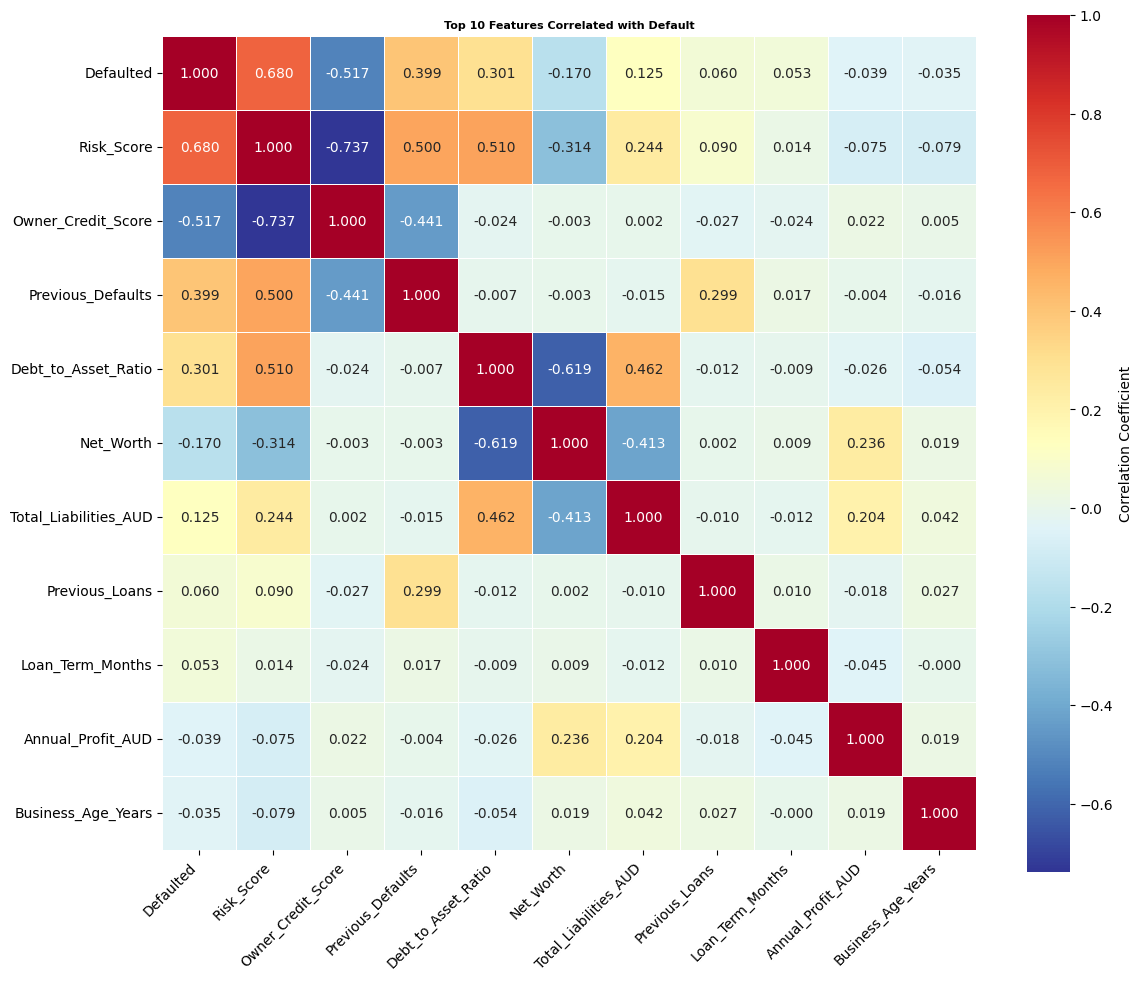

In [13]:
# Get top N correlations with Defaulted
n_features = 10
defaulted_corr = df.corr(numeric_only=True)['Defaulted'].drop('Defaulted')
top_features = defaulted_corr.abs().nlargest(n_features).index.tolist()

# Create subset correlation matrix
subset_features = ['Defaulted'] + top_features
subset_corr = df[subset_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(subset_corr, 
            cmap='RdYlBu_r', 
            annot=True, 
            fmt='.3f',
            square=True,
            linewidths=0.5,
            cbar_kws={'label': 'Correlation Coefficient'})

plt.title(f'Top {n_features} Features Correlated with Default', fontsize=8, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Looking at the heatmap correlations with "Defaulted," here are the top  insights that can be gleaned and include: 
- Risk_Score has a strong positive correlation with Defaulted (0.68): As the risk score increases, the likelihood of default increases significantly. This suggests your risk score is a very effective summary feature.
- Owner_Credit_Score has a strong negative correlation with Defaulted (-0.52): Lower credit scores are strongly associated with higher default risk.
- Previous_Defaults is positively correlated (0.40): Borrowers with a history of previous defaults are much more likely to default again.
- Debt_to_Asset_Ratio is positively correlated (0.30): Higher leverage (more debt relative to assets) increases default risk.

#### Task 5 You are able to plan how to visualize data insights effectively for different stakeholders, choose appropriate visualization tools and justify their use

Stakeholders might include:
- Executive Leadership (CEO, CFO, Board Members):Needs high-level summaries, trends, and business impact.
    - Needs: High-level overview, impact on bottom line, strategic implications, quick decision-making. They don't need to see every detail.
    - Focus: Overall model performance (AUC), key drivers of default, financial impact of defaults, risk exposure.
        - Dashboards (Tableau, Power BI, Streamlit, Dash):Interactive, real-time, and can combine multiple KPIs.
            - Default rates over time (line/bar chart)
            - Approval/rejection rates (pie/bar chart)
            - Financial impact (bar chart, summary cards)
            - Geographic distribution (map)
- Risk Management Team (CRO, Risk Analysts): Needs to understand risk drivers, model fairness, and regulatory compliance.
    - Needs: Granular detail, model accuracy, false positives/negatives, specific risk factors, model validation, threshold setting.
    - Focus: Confusion Matrix, ROC Curve details, feature importance, distribution of risk scores, segment-specific default rates.
        - Top features influencing default (bar plot)
        - summary plots for model explainability
        
- Loan Officers/Underwriters
    - Needs: Actionable insights for individual loan applications, understanding why a loan is high-risk, clear guidance.
    - Focus: Individual risk scores, top contributing factors for a specific loan, comparison to similar loans, clear "approve/deny" signals.

- Data Scientists/Analysts
    - Needs: Model mechanics, performance metrics, feature engineering impact, model stability, comparison of algorithms.
    - Focus: All technical metrics (precision, recall, F1, AUC), feature importance, model coefficients, residual analysis, model comparison.


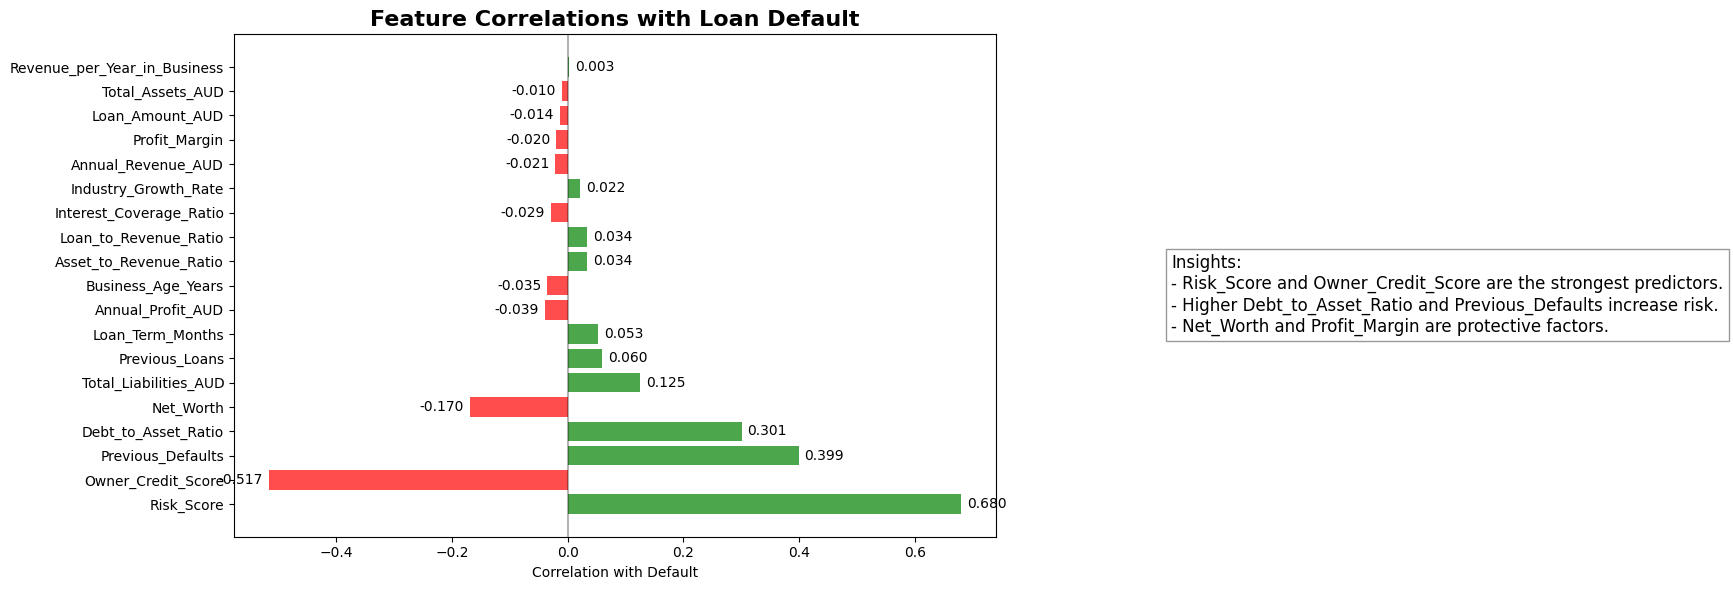

In [14]:
# Get top correlations with Defaulted
defaulted_corr = df.corr(numeric_only=True)['Defaulted'].drop('Defaulted').sort_values(key=abs, ascending=False)

plt.figure(figsize=(12, 6))  # Wider to make room for text
colors = ['red' if x < 0 else 'green' for x in defaulted_corr.values]
bars = plt.barh(range(len(defaulted_corr)), defaulted_corr.values, color=colors, alpha=0.7)

plt.yticks(range(len(defaulted_corr)), defaulted_corr.index)
plt.xlabel('Correlation with Default')
plt.title('Feature Correlations with Loan Default', fontsize=16, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)

# Add value labels on bars
for i, (bar, value) in enumerate(zip(bars, defaulted_corr.values)):
    plt.text(value + (0.01 if value >= 0 else -0.01), i, f'{value:.3f}', 
             va='center', ha='left' if value >= 0 else 'right')

# Add insights 
plt.figtext(
    0.98, 0.5, 
    "Insights:\n"
    "- Risk_Score and Owner_Credit_Score are the strongest predictors.\n"
    "- Higher Debt_to_Asset_Ratio and Previous_Defaults increase risk.\n"
    "- Net_Worth and Profit_Margin are protective factors.",
    fontsize=12, ha='left', va='center',
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray')
)

plt.tight_layout(rect=[0, 0, 0.85, 1])  # Leave space for the sidebar
plt.show()

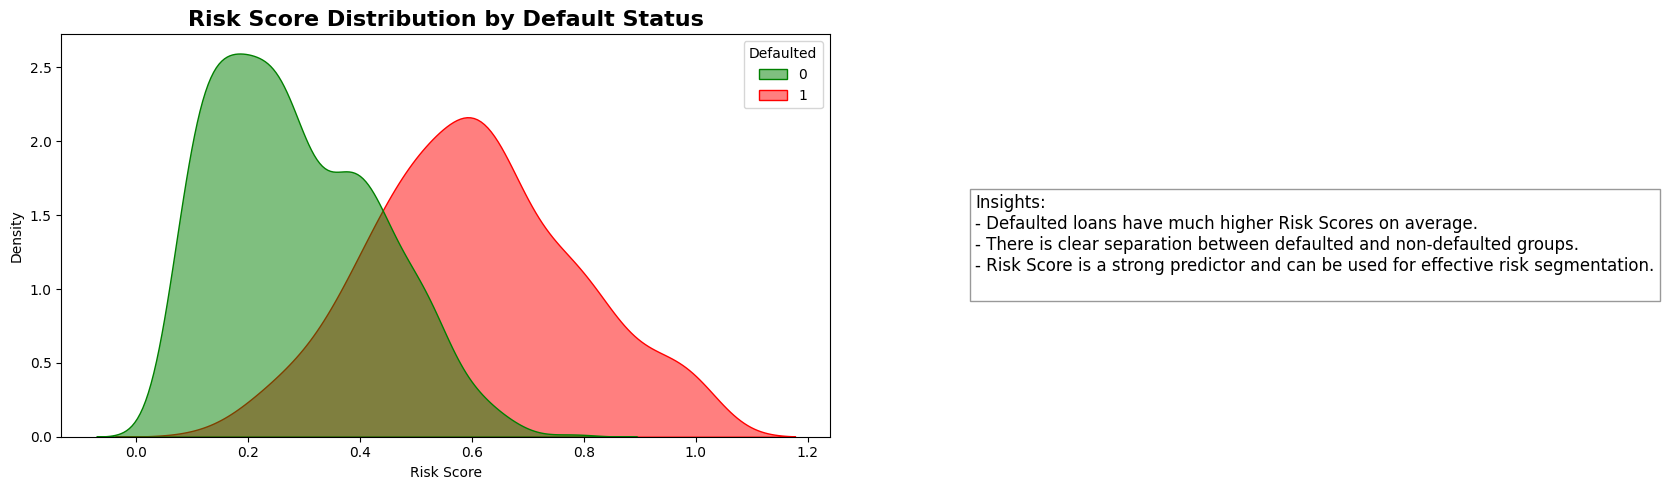

In [15]:
plt.figure(figsize=(10, 5))  # Wider for sidebar

# KDE plot of Risk Score by Defaulted status
sns.kdeplot(
    data=df, 
    x='Risk_Score', 
    hue='Defaulted', 
    fill=True, 
    common_norm=False, 
    alpha=0.5,
    palette={0: 'green', 1: 'red'}
)
plt.title('Risk Score Distribution by Default Status', fontsize=16, fontweight='bold')
plt.xlabel('Risk Score')
plt.ylabel('Density')

# Add insights as a sidebar
plt.figtext(
    0.98, 0.5,
    "Insights:\n"
    "- Defaulted loans have much higher Risk Scores on average.\n"
    "- There is clear separation between defaulted and non-defaulted groups.\n"
    "- Risk Score is a strong predictor and can be used for effective risk segmentation.\n",
    fontsize=12, ha='left', va='center',
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray')
)

plt.tight_layout(rect=[0, 0, 0.85, 1])  # Leave space for sidebar
plt.show()

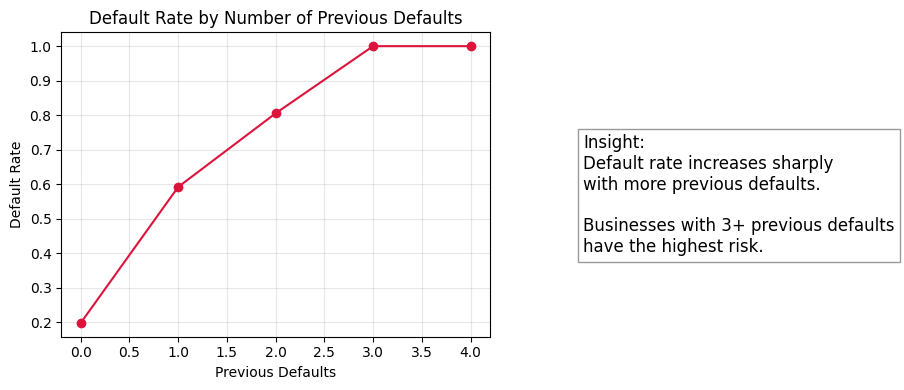

In [16]:
default_rate = df.groupby('Previous_Defaults')['Defaulted'].mean()
plt.figure(figsize=(6, 4))
plt.plot(default_rate.index, default_rate.values, marker='o', color='crimson')
plt.title('Default Rate by Number of Previous Defaults')
plt.xlabel('Previous Defaults')
plt.ylabel('Default Rate')
plt.grid(True, alpha=0.3)

# Add insight text to the right of the chart
plt.figtext(0.98, 0.5, 
            "Insight:\nDefault rate increases sharply\nwith more previous defaults.\n\nBusinesses with 3+ previous defaults\nhave the highest risk.",
            fontsize=12, ha='left', va='center', bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

plt.tight_layout(rect=[0, 0, 0.85, 1])  # Leave space on the right for text
plt.show()

In [17]:
# Create the contingency table
contingency_table = pd.crosstab(df['Previous_Defaults'], df['Defaulted'])

# Calculate default rate for businesses without previous defaults 
no_previous_defaults = contingency_table.loc[0].sum() 
default_rate_no_previous = contingency_table.loc[0, 1] / no_previous_defaults 
# Calculate default rate for businesses with previous defaults 
previous_defaults = contingency_table.loc[1].sum() 
default_rate_previous = contingency_table.loc[1, 1] / previous_defaults 
print(f"Default Rate (No Previous Defaults): {default_rate_no_previous:.2f}") 
print(f"Default Rate (Previous Defaults): {default_rate_previous:.2f}")

Default Rate (No Previous Defaults): 0.20
Default Rate (Previous Defaults): 0.59


 It means that having a history of default significantly increases the likelihood of defaulting again.

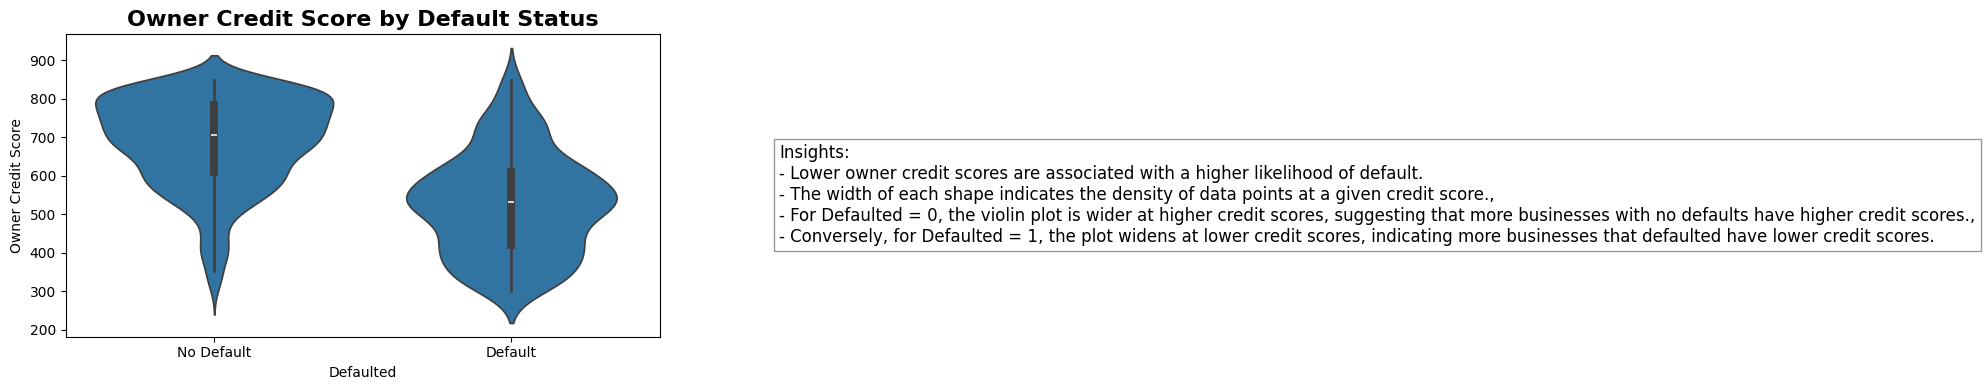

In [18]:
plt.figure(figsize=(8, 4))
sns.violinplot(
    x='Defaulted',
    y='Owner_Credit_Score',
    data=df
)
plt.title('Owner Credit Score by Default Status', fontsize=16, fontweight='bold')
plt.xlabel('Defaulted')
plt.ylabel('Owner Credit Score')
plt.xticks([0, 1], ['No Default', 'Default'])

plt.figtext(
    0.98, 0.5,
    "Insights:\n"
    "- Lower owner credit scores are associated with a higher likelihood of default.\n"
    "- The width of each shape indicates the density of data points at a given credit score.,\n"
    "- For Defaulted = 0, the violin plot is wider at higher credit scores, suggesting that more businesses with no defaults have higher credit scores.,\n"
    "- Conversely, for Defaulted = 1, the plot widens at lower credit scores, indicating more businesses that defaulted have lower credit scores.",
    fontsize=12, ha='left', va='center',
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray')
  )
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

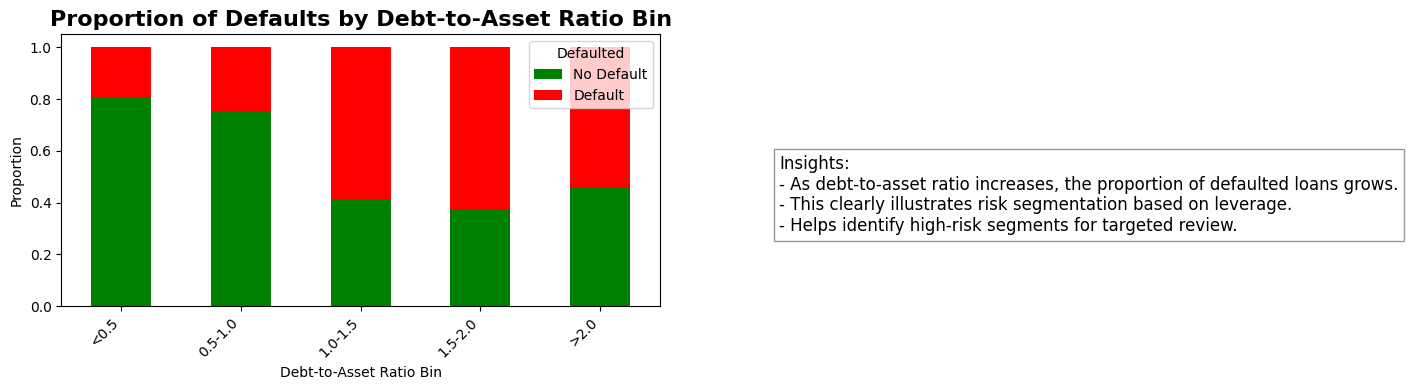

In [19]:
# Ensure Defaulted is integer (if not already)
df['Defaulted'] = df['Defaulted'].astype(int)

# Create bins for Debt_to_Asset_Ratio
bins = [0, 0.5, 1.0, 1.5, 2.0, df['Debt_to_Asset_Ratio'].max() + 0.1]
labels = ['<0.5', '0.5-1.0', '1.0-1.5', '1.5-2.0', '>2.0']
df['Debt_Ratio_Bin'] = pd.cut(df['Debt_to_Asset_Ratio'], bins=bins, labels=labels, right=False)

# Calculate proportions
prop_table = pd.crosstab(df['Debt_Ratio_Bin'], df['Defaulted'], normalize='index').reindex(labels)

prop_table.plot(kind='bar', stacked=True, color=['green', 'red'], figsize=(8, 4))
plt.title('Proportion of Defaults by Debt-to-Asset Ratio Bin', fontsize=16, fontweight='bold')
plt.xlabel('Debt-to-Asset Ratio Bin')
plt.ylabel('Proportion')
plt.legend(['No Default', 'Default'], title='Defaulted')
plt.xticks(rotation=45, ha='right')

plt.figtext(
    0.98, 0.5,
    "Insights:\n"
    "- As debt-to-asset ratio increases, the proportion of defaulted loans grows.\n"
    "- This clearly illustrates risk segmentation based on leverage.\n"
    "- Helps identify high-risk segments for targeted review.",
    fontsize=12, ha='left', va='center',
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray')
)

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

In [20]:
print(df.columns)

Index(['Business_ID', 'Business_Age_Years', 'Industry', 'Region',
       'Annual_Revenue_AUD', 'Annual_Profit_AUD', 'Total_Assets_AUD',
       'Total_Liabilities_AUD', 'Owner_Credit_Score', 'Loan_Amount_AUD',
       'Loan_Term_Months', 'Previous_Loans', 'Previous_Defaults',
       'Industry_Growth_Rate', 'Debt_to_Asset_Ratio', 'Profit_Margin',
       'Loan_to_Revenue_Ratio', 'Net_Worth', 'Revenue_per_Year_in_Business',
       'Interest_Coverage_Ratio', 'Risk_Score', 'Defaulted',
       'Business_Age_Category', 'Credit_Score_Category', 'Loan_Size_Category',
       'Leverage_Category', 'Asset_to_Revenue_Ratio', 'Debt_Ratio_Bin'],
      dtype='object')


                       Total_Defaults
Industry                             
Agriculture                        34
Construction                       42
Education                          19
Healthcare                         16
Hospitality                        43
IT                                 25
Manufacturing                      18
Professional Services              28
Retail                             40
Transport                          23


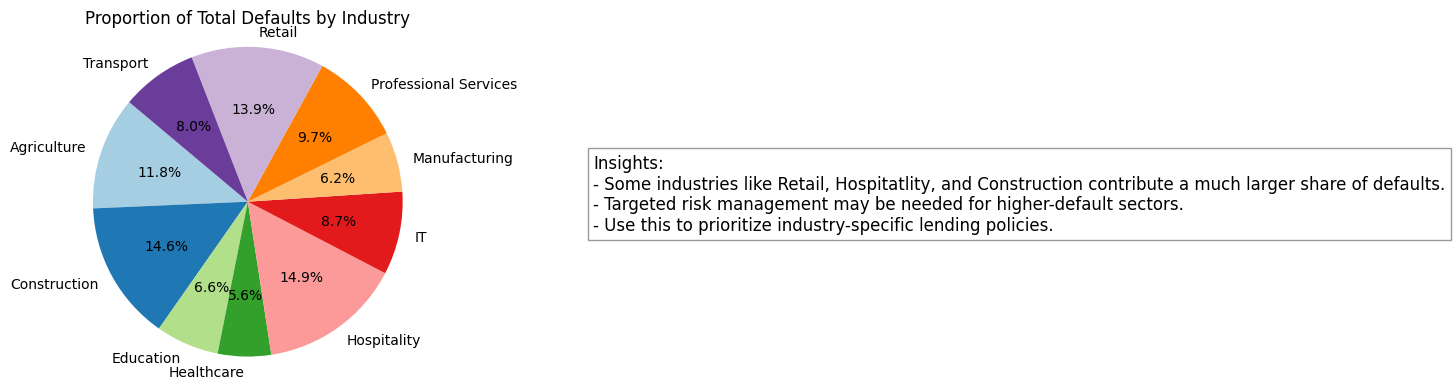

In [21]:
# Group by industry and sum the defaults
df_industry = df.groupby('Industry')['Defaulted'].sum().to_frame(name='Total_Defaults')
print(df_industry)

# Pie chart of total defaults by industry
plt.figure(figsize=(6, 4))
plt.pie(
    df_industry['Total_Defaults'],
    labels=df_industry.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=plt.cm.Paired.colors
)
plt.title('Proportion of Total Defaults by Industry')
plt.axis('equal')
# Add insights as a sidebar
plt.figtext(
    0.98, 0.5,
    "Insights:\n"
    "- Some industries like Retail, Hospitatlity, and Construction contribute a much larger share of defaults.\n"
    "- Targeted risk management may be needed for higher-default sectors.\n"
    "- Use this to prioritize industry-specific lending policies.",
    fontsize=12, ha='left', va='center',
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray')
)

plt.tight_layout(rect=[0, 0, 0.85, 1])  # Leave space for sidebar
plt.show()

        Total_Defaults
Region                
ACT                 34
NSW                 35
NT                  38
QLD                 28
SA                  37
TAS                 35
VIC                 32
WA                  49


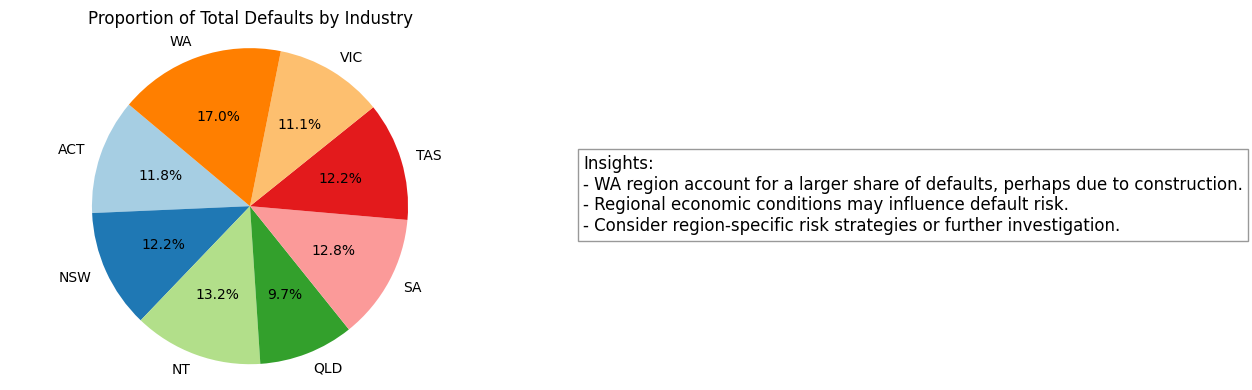

In [22]:
# Group by industry and sum the defaults
df_region = df.groupby('Region')['Defaulted'].sum().to_frame(name='Total_Defaults')
print(df_region)

# Pie chart of total defaults by region
plt.figure(figsize=(6, 4))
plt.pie(
    df_region['Total_Defaults'],
    labels=df_region.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=plt.cm.Paired.colors
)
plt.title('Proportion of Total Defaults by Industry')
plt.axis('equal')

# Add insights 
plt.figtext(
    0.98, 0.5,
    "Insights:\n"
    "- WA region account for a larger share of defaults, perhaps due to construction.\n"
    "- Regional economic conditions may influence default risk.\n"
    "- Consider region-specific risk strategies or further investigation.",
    fontsize=12, ha='left', va='center',
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray')
)

plt.tight_layout(rect=[0, 0, 0.85, 1])  
plt.show()

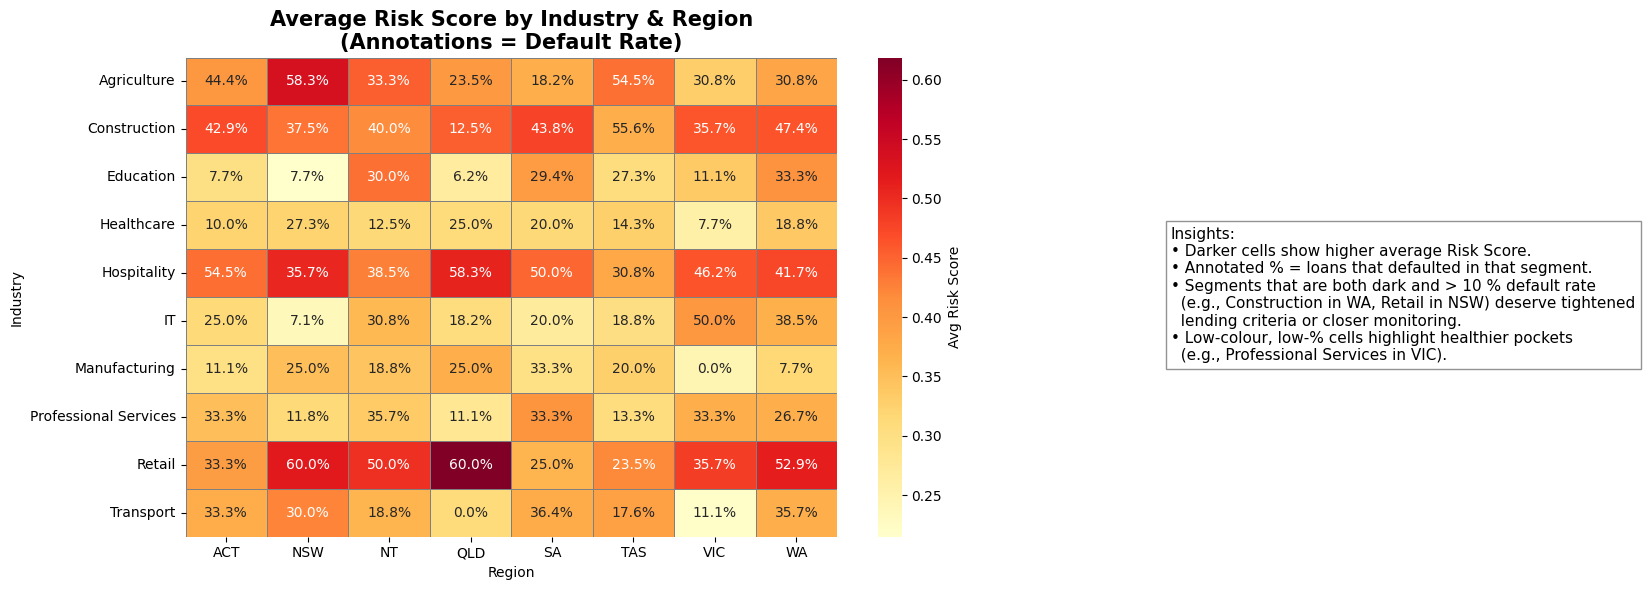

In [23]:
# ── 1.  Build pivot tables ────────────────────────────────────────────────
risk_pivot = (df
              .pivot_table(index='Industry',
                           columns='Region',
                           values='Risk_Score',
                           aggfunc='mean'))

default_pivot = (df
                 .pivot_table(index='Industry',
                              columns='Region',
                              values='Defaulted',
                              aggfunc='mean'))   # mean = default rate

# ── 2.  Plot heatmap with default-rate annotations ───────────────────────
plt.figure(figsize=(12, 6))                       
sns.heatmap(risk_pivot,
            cmap='YlOrRd',                       
            linewidths=.4,
            linecolor='grey',
            annot=default_pivot.applymap(lambda x: f'{x:.1%}'),
            fmt='',
            cbar_kws={'label': 'Avg Risk Score'})

plt.title('Average Risk Score by Industry & Region\n(Annotations = Default Rate)',
          fontsize=15, fontweight='bold')
plt.xlabel('Region')
plt.ylabel('Industry')

# ── 3.  Add  insights on the right ────────────────────────────
plt.figtext(
    0.98, 0.5,
    "Insights:\n"
    "• Darker cells show higher average Risk Score.\n"
    "• Annotated % = loans that defaulted in that segment.\n"
    "• Segments that are both dark and > 10 % default rate\n"
    "  (e.g., Construction in WA, Retail in NSW) deserve tightened\n"
    "  lending criteria or closer monitoring.\n"
    "• Low-colour, low-% cells highlight healthier pockets\n"
    "  (e.g., Professional Services in VIC).",
    ha='left', va='center', fontsize=11,
    bbox=dict(facecolor='white', alpha=0.85, edgecolor='grey')
)

plt.tight_layout(rect=[0, 0, 0.85, 1])   
plt.show()

In [24]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (precision_score,recall_score,f1_score,accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
    auc
)


The dataset is devided into:
- Training Data: The training dataset is used to teach the machine learning model.
- Test Data: a separate portion of the dataset that the model has never seen before and will use it to evaluate how well the trained trained model performs on new, unseen data.
    - It helps you check for overfitting (when a model memorizes the training data but fails to generalize).
    

In [25]:
# Assuming X_encoded and y are already defined
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

# Scale numerical features
scaler = StandardScaler()

# Get numerical column names after encoding
numerical_cols_encoded = [col for col in X_encoded.columns if col in numerical_features]

# Fit scaler on training data only
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_cols_encoded] = scaler.fit_transform(X_train[numerical_cols_encoded])
X_test_scaled[numerical_cols_encoded] = scaler.transform(X_test[numerical_cols_encoded])

# Processing summary
print("\n" + "="*50)
print("PREPROCESSING SUMMARY")
print("="*50)
print(f"Original dataset shape: {df.shape}")
print(f"Final training set shape: {X_train_scaled.shape}")
print(f"Final test set shape: {X_test_scaled.shape}")
print(f"Target distribution in training set:")
print(y_train.value_counts(normalize=True))

print("\nPreprocessing complete! Ready for model training.")


PREPROCESSING SUMMARY
Original dataset shape: (1000, 28)
Final training set shape: (800, 46)
Final test set shape: (200, 46)
Target distribution in training set:
0    0.7125
1    0.2875
Name: Defaulted, dtype: float64

Preprocessing complete! Ready for model training.


#### Task 6 You are able to propose machine learning algorithms suitable for the application, and justify the choice of algorithms based on the nature of the data and the expected outcomes

I chose a few models to train on, and based on the results, including: Accuracy,  Precision,  Recall,  F1 Score, AUC reviewed the results and proposed the best model for making loan decisions.

Based on the above output results and default prediction dataset, the best models to hypertune are those that:
- Handle both numerical and categorical features well
- Can model non-linear relationships
- Are robust to outliers and feature interactions
- Are interpretable or widely used in credit risk modeling

Gradient Boosting (e.g., XGBoost, GradientBoostingClassifier)
- Excels with tabular, structured data
- Handles non-linearities and feature interactions
- XGBoost is especially robust and tunable

Random Forest
- Great baseline for tabular data
- Handles missing values and outliers well
- Less prone to overfitting than single decision trees
- Provides feature importance for interpretability

Logistic Regression
- Highly interpretable (important for finance and compliance)
- Good baseline, especially if relationships are mostly linear
- Fast to train and easy to explain to stakeholders


In [26]:
# Bundle a few models with standard paaraneters to determine and output performance summary
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'SVM': SVC(random_state=42, probability=True),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss')
}


# Store predictions and probabilities
y_preds = {}
y_probas = {}
model_scores = {}

print("Training models...")
print("=" * 50)

for name, model in models.items():
    print(f"Training {name}...")
    
    # Train the model
    model.fit(X_train_scaled, y_train)
    
    # Make predictions
    y_preds[name] = model.predict(X_test_scaled)
    y_probas[name] = model.predict_proba(X_test_scaled)[:, 1]
    
    # Calculate AUC score
    fpr, tpr, _ = roc_curve(y_test, y_probas[name])
    roc_auc = auc(fpr, tpr)
    model_scores[name] = roc_auc
    
    print(f"✓ {name} - AUC: {roc_auc:.3f}")

print("\nTraining complete!")

# Display model performance summary
print("\nModel Performance Summary:")
print("-" * 40)
for name, score in sorted(model_scores.items(), key=lambda x: x[1], reverse=True):
    print(f"{name:20}: {score:.3f}")

Training models...
Training Logistic Regression...
✓ Logistic Regression - AUC: 0.911
Training Random Forest...
✓ Random Forest - AUC: 0.899
Training Gradient Boosting...
✓ Gradient Boosting - AUC: 0.913
Training SVM...
✓ SVM - AUC: 0.898
Training XGBoost...
✓ XGBoost - AUC: 0.892

Training complete!

Model Performance Summary:
----------------------------------------
Gradient Boosting   : 0.913
Logistic Regression : 0.911
Random Forest       : 0.899
SVM                 : 0.898
XGBoost             : 0.892


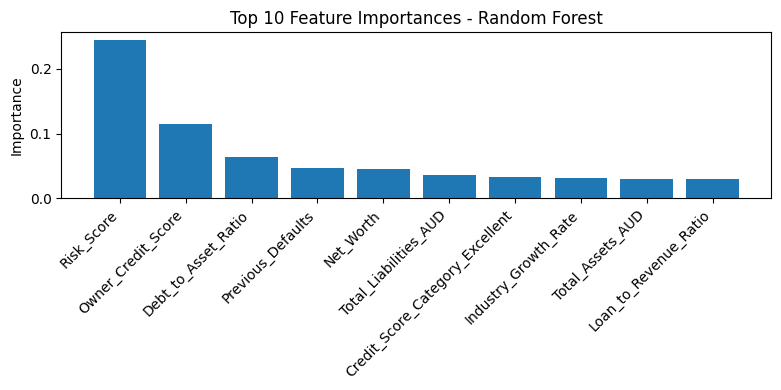

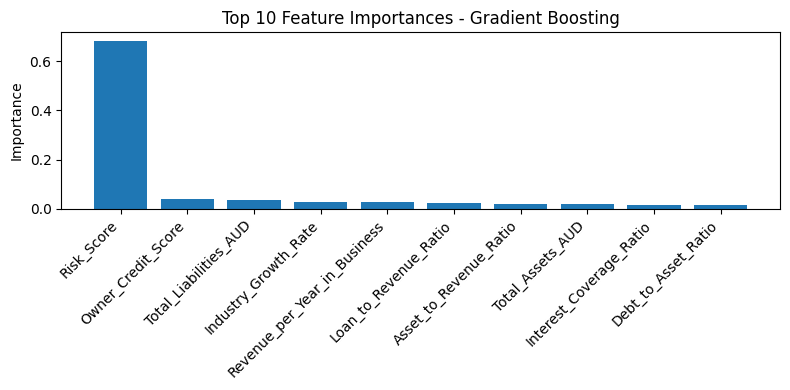

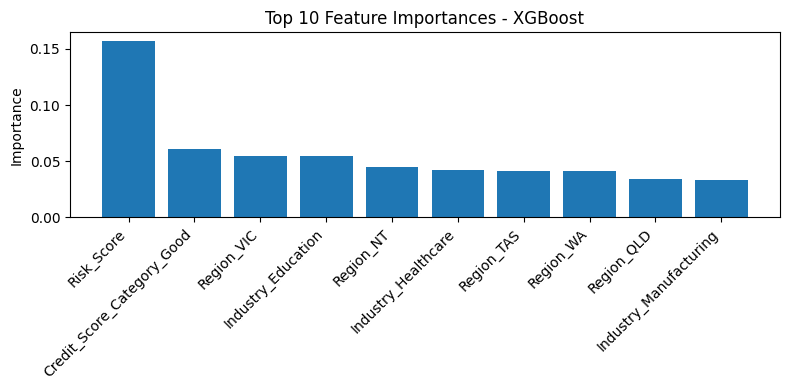

In [27]:
# Feature importance for tree-based models
tree_models = ['Random Forest', 'Gradient Boosting', 'XGBoost']
for model_name in tree_models:
    #print (model_name)
    if model_name in models:
        model = models[model_name]
        #print (model)
        if hasattr(model, 'feature_importances_'):
            importances = model.feature_importances_
            # print (importances)
            feature_names = X_train_scaled.columns if hasattr(X_train_scaled, 'columns') else [f'Feature_{i}' for i in range(len(importances))]
            
            # Get top 10 features
            indices = np.argsort(importances)[::-1][:10]
            
            plt.figure(figsize=(8, 4))
            plt.title(f'Top 10 Feature Importances - {model_name}')
            plt.bar(range(10), importances[indices])
            plt.xticks(range(10), [feature_names[i] for i in indices], rotation=45, ha='right')
            plt.ylabel('Importance')
            plt.tight_layout()
            plt.show()

The top drivers of model predictions for each tree-based model, helping you understand, explain, and potentially improve your risk models and business decisions.
- Risk Score is common amongst Random Forest, Gradient Boosting and XGBoost tree models

##### **I had to balance hypertuning with training time /cpu usage**

In [28]:

# ── 1. Logistic Regression ──────────────────────────────────────────────
''' This code automatically finds the best regularization strength and solver for Logistic Regression by exhaustively testing all combinations, 
using cross-validation and AUC as the performance metric. 
The result is a model that is tuned for optimal predictive performance on your dataset.'''

param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs']
}

''' GridSearchCV is a tool that automates the process of trying every combination in the parameter grid.'''
grid_search_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid_lr, cv=5, scoring='roc_auc', n_jobs=-1
)

# ── 2. Random Forest ────────────────────────────────────────────────────
''' This code systematically tunes Random Forest settings to maximize predictive performance, ensuring you get the most out of the model for your business loan default prediction task.'''
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
grid_search_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf, cv=5, scoring='roc_auc', n_jobs=-1
)

# ── 3. Gradient Boosting ────────────────────────────────────────────────
'''This code systematically tunes Gradient Boosting settings to maximize predictive performance, ensuring you get the best possible model for your business loan default prediction task.'''
param_grid_gb = {
    'n_estimators': [50],        # Fewer trees
    'learning_rate': [0.1],      # Default, balances speed and performance
    'max_depth': [3],            # Shallow trees, fast to train
    'min_samples_split': [2]     # Default
}

grid_search_gb = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid_gb, cv=5, scoring='roc_auc', n_jobs=-1
)


# ── 4. XGBoost ───────────────────────────────────────────────────────────
"Systematically tunes XGBoost settings to maximize predictive performance, ensuring you get the best possible model for your business loan default prediction task.."
param_grid_xgb = {
    'n_estimators': [50],        # Fewer trees
    'learning_rate': [0.1],      # Default
    'max_depth': [3],            # Shallow trees
    'subsample': [1.0],          # Use all data for each tree
    'colsample_bytree': [1.0]    # Use all features for each tree

}
grid_search_xgb = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    param_grid_xgb, cv=5, scoring='roc_auc', n_jobs=-1
)

# ── 4. SVM ───────────────────────────────────────────────────────────
param_grid_svm = {
    'C': [0.1, 1],           # Regularization strength: just two values
    'kernel': ['linear'],    # Linear kernel is much faster than 'rbf'
}

grid_search_svm = GridSearchCV(
    SVC(probability=True, random_state=42),
    param_grid_svm,cv=5,scoring='roc_auc',n_jobs=-1
)

# ── 5. Create Models Dictionary ─────────────────────────────────────────
models = {
    'Logistic Regression': grid_search_lr,
    'Random Forest': grid_search_rf,
    'Gradient Boosting': grid_search_gb,
    'XGBoost': grid_search_xgb,
    'SVM': grid_search_svm
}

print("Hyperparameter tuning setup complete!")
print(f"Total models to tune: {len(models)}")

Hyperparameter tuning setup complete!
Total models to tune: 5


#### Task 7 You are able to define the specific outputs expected from the AI model and discuss how these outputs will address the problem or improve the application

1. Specific Outputs Expected from the AI Model
    - Primary Output
        - Default Prediction:
            - For each loan application, the model outputs a binary prediction:
            - 1 = Will default
            - 0 = Will not default
    - Secondary Outputs
        - Probability Score:
            - For each application, the model provides a probability (e.g., 0.87) that the loan will default.
            - This allows for risk ranking and threshold adjustment.
    - Feature Importance:
        - For tree-based models, the model can output the relative importance of each feature (e.g., credit score, debt-to-asset ratio) in making its predictions.
        - Model Confidence/Uncertainty:
        - Some models can provide a measure of confidence or uncertainty in their predictions.
    - Evaluation Metrics (for model monitoring)
        - Confusion Matrix:
        - Counts of true positives, false positives, true negatives, and false negatives.
        - Performance Scores:
        - Metrics such as accuracy, precision, recall, F1 score, and AUC-ROC.

2. How These Outputs Address the Problem or Improve the Application
    - Improved Risk Assessment
        - Automated, data-driven predictions help underwriters quickly identify high-risk applications, reducing manual review time and human error.
        - Probability scores allow for nuanced decision-making (e.g., flagging borderline cases for further review).
    - Business Impact
        - Reduce loan defaults:
            - By accurately flagging likely defaulters, the business can avoid approving risky loans, directly reducing financial losses.
            - Increase approval of good loans:
            - By minimizing false positives, the business can confidently approve more low-risk loans, increasing revenue.
    - Operational Efficiency
        - Faster processing:
            - Automated predictions mean faster turnaround for loan applications.
            - Scalability:
            - The model should be able to handle large volumes of applications without additional staffing.
    - Regulatory and Stakeholder Transparency
        - Feature importance and clear metrics provide transparency for regulators and stakeholders, showing how decisions are made and which factors are most influential.
    - Continuous Improvement
        - Evaluation metrics allow ongoing monitoring and retraining, ensuring the model adapts to changing economic conditions or applicant behavior.


Training models...
Training Logistic Regression...
✓ Logistic Regression - AUC: 0.915
Training Random Forest...
✓ Random Forest - AUC: 0.901
Training Gradient Boosting...
✓ Gradient Boosting - AUC: 0.912
Training XGBoost...
✓ XGBoost - AUC: 0.910
Training SVM...
✓ SVM - AUC: 0.904

Training complete!

Model Performance Summary:
----------------------------------------
Logistic Regression : 0.915
Gradient Boosting   : 0.912
XGBoost             : 0.910
SVM                 : 0.904
Random Forest       : 0.901


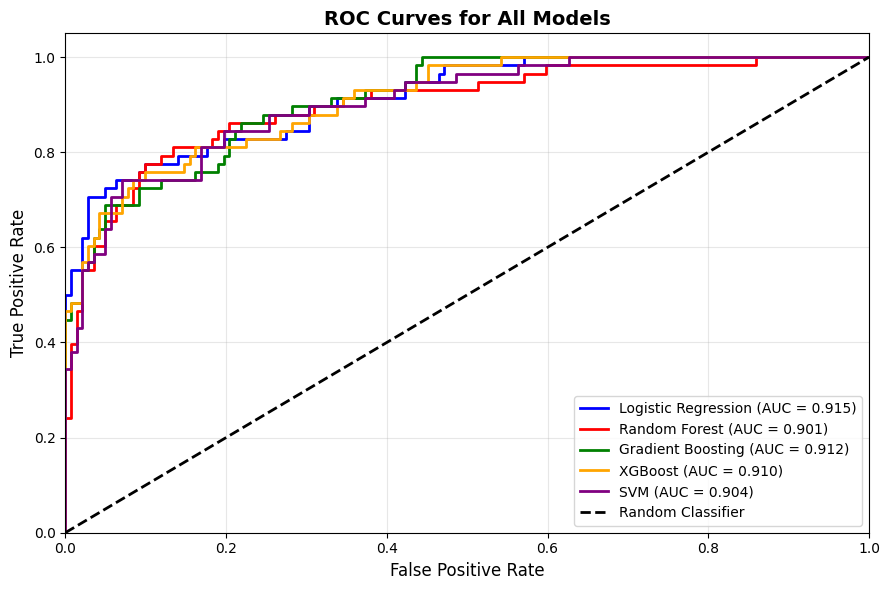

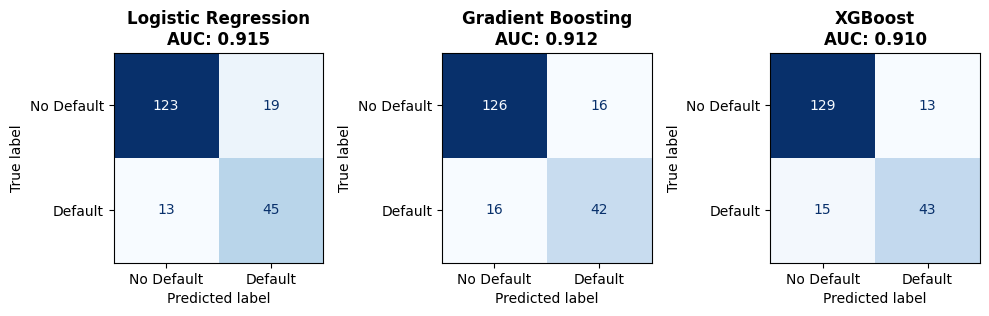

In [33]:
# Lets Train the various models with hypertuning
y_preds = {}
y_probas = {}
model_scores = {}

print("Training models...")
print("=" * 50)

for name, model in models.items():
    print(f"Training {name}...")
    
    # Train the model
    model.fit(X_train_scaled, y_train)
    
    # Make predictions
    y_preds[name] = model.predict(X_test_scaled)
    y_probas[name] = model.predict_proba(X_test_scaled)[:, 1]
    
    # Calculate AUC score
    fpr, tpr, _ = roc_curve(y_test, y_probas[name])
    roc_auc = auc(fpr, tpr)
    model_scores[name] = roc_auc
    
    print(f"✓ {name} - AUC: {roc_auc:.3f}")

print("\nTraining complete!")

# Display model performance summary
print("\nModel Performance Summary:")
print("-" * 40)
for name, score in sorted(model_scores.items(), key=lambda x: x[1], reverse=True):
    print(f"{name:20}: {score:.3f}")

# Plot ROC curves
plt.figure(figsize=(9, 6))
colors = ['blue', 'red', 'green', 'orange', 'purple']

for i, name in enumerate(models.keys()):
    fpr, tpr, _ = roc_curve(y_test, y_probas[name])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], lw=2, 
             label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves for All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot confusion matrices (showing top 3 models)
top_3_models = sorted(model_scores.items(), key=lambda x: x[1], reverse=True)[:3]
fig, axes = plt.subplots(1, 3, figsize=(10, 5))
for ax, (name, _) in zip(axes, top_3_models):
    cm = confusion_matrix(y_test, y_preds[name])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Default', 'Default'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nAUC: {model_scores[name]:.3f}', fontweight='bold')

plt.tight_layout()
plt.show()

In [30]:
results = [] 
for name in model_scores.keys():
    y_pred = y_preds[name]
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    accuracy = accuracy_score(y_test, y_pred)
    auc_score = model_scores[name]
    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'AUC': auc_score
    })

results_df = pd.DataFrame(results).set_index('Model')
print(results_df.round(3))

                     Accuracy  Precision  Recall  F1 Score    AUC
Model                                                            
Logistic Regression     0.840      0.703   0.776     0.738  0.915
Random Forest           0.865      0.763   0.776     0.769  0.901
Gradient Boosting       0.840      0.724   0.724     0.724  0.912
XGBoost                 0.860      0.768   0.741     0.754  0.910
SVM                     0.830      0.694   0.741     0.717  0.904


In [31]:
# preparing new (unseen) data—such as application predictions with a model that has already been trained.
'''The new data (e.g., a new loan application) might not have all the same one-hot encoded columns as the training data, or the columns might be in a different order.
Adds any missing columns (with zeros) to the new data.
Reorders columns to match the training data.
Applies the already-fitted scaler to the numerical columns.'''

for col in X_encoded.columns:
    if col not in df_application.columns:
        df_application[col] = 0
df_application = df_application[X_encoded.columns]  # Ensure column order matches

# Scale numerical features
df_application_scaled = df_application.copy()
df_application_scaled[numerical_cols_encoded] = scaler.transform(df_application[numerical_cols_encoded])

Now validate model against a smaller "application" data 

In [32]:
# Predict default (0 = not defaulted, 1 = defaulted)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
application_pred = rf.predict(df_application_scaled)
application_proba = rf.predict_proba(df_application_scaled)[:, 1]

# Add predictions to DataFrame
df_application['Predicted_Default'] = application_pred
df_application['Default_Probability'] = application_proba

print(df_application[['Predicted_Default', 'Default_Probability']])

   Predicted_Default  Default_Probability
0                  0                 0.06
1                  0                 0.08
2                  0                 0.08
3                  1                 0.82
4                  0                 0.07
5                  0                 0.13
6                  0                 0.13
7                  0                 0.31
8                  0                 0.09
9                  0                 0.16


Application 3 has a predicated default with high probability. 
Application 7 does not have predicted default, but probablity is highish. This could be used to set tighter terms & conditions or higher interest rates to reflect the extra risk.

#### Task 8 You are able to plan the testing phases for the AI model, including both validation and verification and describe methods to measure model accuracy, precision, and other relevant metrics

1. Verification Phase
    - Verification ensures the model is built correctly according to specifications and requirements.
        - Code Review: Conduct systematic reviews of code, data pipelines, and feature engineering steps to ensure correctness and reproducibility.
        - Unit Testing: Test individual components (e.g., data preprocessing, feature extraction) to confirm they function as intended.
        - Integration Testing: Ensure all components work together seamlessly, from data ingestion to model output.
        - Data Integrity Checks: Validate that input data is correctly formatted, complete, and free from corruption or leakage.
2. Validation Phase
    - Validation ensures the model performs well on real-world data and meets business objectives.
        - Train/Test Split: Divide the dataset into training, validation, and test sets (e.g., 70/15/15 split) to evaluate model generalization.
        - Cross-Validation: Use k-fold cross-validation to assess model stability and performance across different data subsets.
        - Holdout Set Evaluation: Reserve a final holdout set (never seen during training or tuning) for unbiased performance assessment.
        - Business Scenario Testing: Simulate real-world scenarios and edge cases to evaluate model robustness and reliability.

3. Metrics
    - Accuracy: The proportion of total predictions that were correct.
        - It gives you a general sense of how often your model is right.
        - All three models perform very well (AUC > 0.91), andare excellent at distinguishing between defaults and non-defaults.
        - XGBoost has the highest number of true negatives (129) and the lowest false positives (13), meaning it is slightly more conservative in predicting defaults.
        - Logistic Regression has the highest true positives (45), meaning it catches the most actual defaults, but at the cost of more false positives (19).
        - Gradient Boosting is in between, with a slightly higher number of false negatives (16) compared to the others.

        - As the goal was to  make more informed decisions and reduce risks for both the bank and the businesses then Logistical Regression (with highest AUC, and F1 Score), might be the right model.

    - Precision (Positive Predictive Value): Out of all the instances your model predicted as positive (default), how many were actually positive?
        - High precision means when your model flags a loan as "default risk," it's very likely to be correct.
        - Use When the cost of a False Positive (FP) is high.
    - Recall / Sensitivity (True Positive Rate): Out of all the instances that were actually positive (default), Did my model correctly identify them.
        - High recall means your model is good at catching most of the actual defaulting loans.
        - use when the cost of a False Negative (FN) is high.
    - F1 Score: The harmonic mean of Precision and Recall. It provides a single score that balances both.
        - Useful when you need a balance between catching all defaults (Recall) and not having too many false alarms (Precision).
        - Use when you have an imbalanced dataset and want to ensure good performance on the minority class without overly favoring one metric.


#### Task 9 You are able to discuss ethical considerations related to data privacy, accuracy and explainability and propose measures to address potential ethical issues in the model's application

- Financial services often involve processing sensitive personal data, including customer and related financial information. Ethical considerations for protecting this sensitive information necessitate implementing powerful techniques such as: 
    - Proposed Measures for Data Privacy:
        - Limit data collection to only what is necessary for model development.
        - Anonymise and encrypt data both at rest and in transit.
        - Implement strict access controls and maintain audit logs of data usage.
        - Regularly review data handling practices for compliance with relevant laws and internal policies.
        - Ensure transparency with customers about data usage and obtain explicit consent.
    - Proposed Measures for Ethical considerations:
        - Conduct thorough data quality checks and clean data before model training.
        - Perform bias audits to identify and mitigate any unfair impact on protected groups.
        - Continuously monitor model performance and retrain as necessary to adapt to new data patterns.
        - Use model predictions as decision support, not as the sole basis for loan approvals or denials, ensuring human oversight.
    - Proposed Measures for Ethical considerations:
        - Use interpretable models where possible, or apply explainability tools (such as SHAP or LIME) to clarify how predictions are made.
        - Provide clear, understandable explanations for model decisions to both internal stakeholders and customers.
        - Maintain comprehensive documentation of model design, data sources, and decision logic for transparency and auditability.
        - 
- Current AI solutions, including deep learning techniques such as neural networks, are often called "black box" models. This lack of transparency can raise ethical concerns, especially in financial decision-making, where understanding how AI reaches its conclusions is critical. It is recommended to use explainable AI and models to improve transparency in financial AI applications. These approaches can alleviate user concerns and build greater stakeholder trust and reliability. In a highly regulated financial environment, ensuring that the decision-making process remains clear and reasonable is critical. Users must understand all the intermediate steps leading to AI-driven decisions to build trust and ensure accountability.

- Avoid Algorithmic bias which can  lead to unfair or discriminatory outcomes that affect lending, investment, and risk management decisions by 
    - ensure the training data is representative and accurately reflects different populations. In addition, it is essential to develop and implement complex integrated models specifically for financial data. These models must be carefully designed to mitigate bias and promote fair decision-making processes, emphasising the importance of ethical AI practices and an AI development process prioritising fairness and diversity.


#### Task 10 You are able to explain how to evaluate the model using metrics like true positives and false negatives, and outline plans for adjusting the model based on these metrics

- True Positive (TP): Correctly predicted default. (Model said default, it defaulted)
- True Negative (TN): Correctly predicted no default. (Model said no default, it didn't default)
- False Positive (FP): Incorrectly predicted default (Type I error). (Model said default, but it didn't) - This is a "false alarm" or "missed opportunity" for a good loan.
- False Negative (FN): Incorrectly predicted no default (Type II error). (Model said no default, but it defaulted) - This is a "missed risk" or "bad loan approved".

- Practical Plan for Model Adjustment
    - Evaluate the confusion matrix and key metrics on your validation/test set.
    - Identify which errors are most costly for your business (FN or FP).
    - Adjust the model:
    - Change the classification threshold.
    - Tune hyperparameters.
    - Try different algorithms.
    - Engineer new features.
    - Use resampling if classes are imbalanced.
    - Re-evaluate after each adjustment.
    - Repeat until you reach a satisfactory balance for your use case.

Actions to take:
- Too Many False Negatives (FN): Then the model is missing actual defaults (bad loans slip through).  
    - lower the classification threshold (e.g., predict default if probability > 0.3 instead of 0.5).
    - Use a model that maximizes recall.
    - Add or engineer features that help identify defaults.
    - Try resampling techniques (oversample defaults or undersample non-defaults).
- Too Many False Positives (FP):Then the model is flagging too many good loans as defaults (missed business).
    - Raise the classification threshold (e.g., predict default only if probability > 0.7).
    - Use a model that maximizes precision.
    - Refine features to better distinguish between classes.
- For Balance: Use the F1 Score or AUC-ROC to find a good trade-off between precision and recall.
    - Adjust the threshold to find the best balance for your business needs.
 

